In [59]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [60]:
from pathlib import Path

model_path = Path("face_landmarker.task")

print(model_path.resolve())
print(model_path.exists())



/Users/evedurant/Desktop/facemetric-api/models/face_landmarker.task
True


In [61]:


# this dewscribes where the trained model is stored
base_options = python.BaseOptions(model_asset_path=str(model_path))

# this configures how the face landmarker should behave
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
# detector uses options from above
detector = vision.FaceLandmarker.create_from_options(options)

I0000 00:00:1786388476.718101  604574 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 83), renderer: Apple M2


W0000 00:00:1786388476.741107  604574 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


In [ ]:

def get_detection_result_takes_path(img_path:str):
    """
    Takes in an image path and runs mediapipe on image.
    
    returns detection_result
        
    """
    #bgr image
    bgr_image = cv.imread(img_path)
        
    if bgr_image is None:
        raise FileNotFoundError( f"opencv cant read image")

    #change to rgb image    
    rgb_image = cv.cvtColor(
        bgr_image,
        cv.COLOR_BGR2RGB,
    )
        
    rgb_image = np.ascontiguousarray(
        rgb_image,
        dtype=np.uint8,
    )
        
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image, )
        
    # detect landmarks 
    detection_result = detector.detect(mp_image)
    return detection_result




def run_mediapipe_extract_symmetry_points(detection_result, img) -> np.ndarray:
    """
    Takes in an detection result and an image returns an x array and y array
    of points along the centre of the face
    """

    # finds the first (and only in this case) face detected by detection_result
    first_face = detection_result.face_landmarks[0]

    h, w = img.shape[:2]

    # the list of features that are meant to be in the centre of the face and 
    # their index with detection_result
    FEATURES = {"nose_tip": 1, "upper_lip": 13, "upper_face": 10, "chin": 152,}

    
    x = []
    y = []

    for feature_name, landmark_index in FEATURES.items():

        # each separate point in list of face landmarks
        landmark = first_face[landmark_index]

        pixel_x =  int(landmark.x * w)
        pixel_y = int(landmark.y * h)

        x.append(pixel_x)
        y.append(pixel_y)
        
    return x, y
        
def get_angle_of_rotation(img, x, y):
    """ Takes in an image and x and y arrays and 
    returns the angle the face makes iwth the vertical
    and the change in x that the rotation would create
    """
    height, _, _ = img.shape
    # this is the line of best fit that goes through the point in 
    # the x and y array in the form y = ax + b
    a, b = np.polyfit(x, y, 1)

    # now we find points x0, y0 where the line would cross the 
    # top of the image by rearranging y = ax+b to x = (y-b)/a
    # y0 is zero at the top of the image
    y0 = 0
    x0 = int((y0-b)/a)
    print(f"x0: {x0}")
    # here we find the point where this line would cross the bottom
    #  of the image, i.e the height for the y value
    y1 = height
    print(f"y1 = {y1}")
    x1 = int((y1 - b)/a)

    # find change in x and chnage in y
    delta_x = x1 - x0
    delta_y = y1 - y0

    # find angle that the line of best fit makes with the vertical
    #  using trigonomatry
    theta = np.arctan(delta_x/delta_y)
    theta = np.rad2deg(theta)

    return theta, delta_x






In [64]:
img_path = r'/Users/evedurant/Desktop/facemetric-api/tests/ben.jpeg'

def rotate_image(img, angle, delta_x) -> np.ndarray:
    """ rotates an image around its center and crops it by delta_x on all sides
    """
    h, w = img.shape[:2]
    centre = (w/2, h/2)
    print(f"theta: {angle}")
    rotation_matrix = cv.getRotationMatrix2D(center=centre,angle=-angle,scale=1.0,)

    rotated_img = cv.warpAffine(
        img,
        rotation_matrix,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderMode=cv.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )

    delta_x = abs(delta_x)

    cropped_img = rotated_img[delta_x:h - delta_x, delta_x: w - delta_x]
                                             

    return cropped_img





In [57]:
def rotate(img_path):
    """ Takes in an image path and returns a rotated image based
    on features of the face 
    """

    img = cv.imread(img_path)
    detection_result = get_detection_result_takes_path(img_path)
    x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
    theta, delta_x = get_angle_of_rotation(img, x, y)
    cropped_img = rotate_image(img, theta, delta_x)
    cropped_img = cv.cvtColor(
            cropped_img,
            cv.COLOR_RGB2BGR)
    return cropped_img


    

x0: 491
y1 = 1690
theta: -1.0169780307191734


(np.float64(-0.5), np.float64(890.5), np.float64(1629.5), np.float64(-0.5))

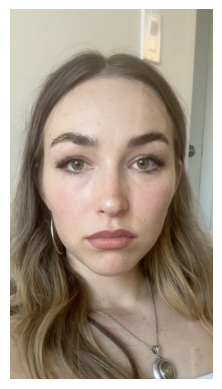

In [65]:
img_path = r'/Users/evedurant/Desktop/facemetric-api/tests/face.jpg'
cropped_img = rotate(img_path)


plt.imshow(cropped_img)
plt.axis('off')

Below is a working function that takes in an image path and returns a map of normalized facial landmarks with the line fo symmetry down the face being vertical

In [66]:
def rotate_landmarks(img_path):
    """ Takes in an img_path, detects key landmarks, detects
    the tilt of the face, theta, and rotates the facial landmarks
    by theta. Returns the rotated facial landmarks.
    """
    img = cv.imread(img_path)
    
    img = cv.cvtColor(
        img,
        cv.COLOR_BGR2RGB,
    )

    #rotated_img = rotate(img_path)
    detection_result = get_detection_result_takes_path(img_path)
    face = detection_result.face_landmarks[0]

    h, w, _ = img.shape
    centre = (w/2, h/2)
    x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
    theta, delta_x = get_angle_of_rotation(img, x, y)
    theta = np.rad2deg(theta)
    rotation_matrix = cv.getRotationMatrix2D(centre ,angle=-theta,scale=1.0,)

    delta_x = abs(delta_x)

    for landmark in face:
        x = landmark.x * w
        y = landmark.y * h

        # each point needs to be a 3d matrix since the opencv matrix has 3 columns
        point = np.array([x, y, 1.0])

        rotated_x, rotated_y = np.dot(rotation_matrix, point)

        rotated_x = (rotated_x - delta_x)/w
        rotated_y = (rotated_y - delta_x)/h

        landmark.x = float(rotated_x)
        landmark.y = float(rotated_y)

    return face